# Tamaño y rol direccional sectorial

Autor:  Carlos González
Fecha:  Mayo 2026
Ultima actualizacion: Mayo 2026

**Tesis - Contagio predictivo sectorial y NBFIs en Chile**

Este notebook implementa la **caracterización de la red financiera sectorial** sobre datos CNSI del Banco Central de Chile (matriz who-to-whom, 2003T1–2025T3).

El objetivo es responder dos preguntas que el lector necesita resolver antes de leer cualquier ejercicio de contagio:

1. **¿Qué tan grande es cada sector dentro del sistema?** Medido vía *strength dirigido* (in y out) ponderado por flujos efectivos.
2. **¿Qué rol funcional cumple cada sector?** Medido vía *asimetría direccional*: ¿es neto acreedor, neto deudor, o balanceado?

Estas métricas constituyen la columna vertebral descriptiva. Son las que sobreviven la agregación sectorial y la frecuencia trimestral, y son comparables con la literatura.

## Definiciones formales

Sea $w_{ij,t}$ el saldo del sector $j$ frente al sector $i$ en el trimestre $t$ (es decir, $i$ es acreedor, $j$ es deudor). Las dos métricas centrales son:

$$s_i^{\text{out}}(t) = \sum_{j \neq i} w_{ij,t} \quad\text{(strength como acreedor)}$$

$$s_i^{\text{in}}(t) = \sum_{j \neq i} w_{ji,t} \quad\text{(strength como deudor)}$$

$$\alpha_i(t) = \frac{s_i^{\text{out}}(t)}{s_i^{\text{out}}(t) + s_i^{\text{in}}(t)} \in [0,1]$$

donde $\alpha_i$ es la **asimetría direccional**: valores cercanos a 1 indican sector puro acreedor (financia al resto), cercanos a 0 puro deudor (es financiado), 0.5 balanceado.

> **Nota sobre Fondos de Pensiones**: como las matrices CNSI no registran los pasivos previsionales de los FP con los hogares (ver justificación en sección 2.C de tu tesis), el FP aparece estructuralmente como $\alpha \approx 1$. Esto **no es un artefacto a corregir**, es la representación correcta del rol activo de los FP como financiadores del sistema.

## 1. Setup y carga de datos

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Configuración estética común para toda la tesis
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

BASE_DIR  = Path("../..") #por favor. Agregar path y luego ejecutar.
INPUT_PATH = BASE_DIR / "1_datos/1_clean_data/panel_red_saldos.csv"
OUTPUT_DIR = BASE_DIR / "3_resultados/3_resultados_he_red/figuras/2_indices"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### 1.1 Sectores y etiquetas

Usamos las agrupaciones de la Tabla 1 de la tesis. Distinguimos tres grupos para las visualizaciones:

- **Financieros**: foco del análisis (7 sectores).
- **Sector real y gobierno**: incluidos en algunos paneles como contexto.
- **Resto del mundo**: tratado aparte por su naturaleza.

El orden de los sectores en las figuras sigue una lógica funcional (BC, Bancos, NBFIs, sector real, externo) en lugar del orden numérico SCN.

In [26]:
# Mapeos sector → etiqueta legible
ETIQUETAS = {
    "S121": "BC",
    "S122": "Bancos",
    "S123": "FMM",
    "S124": "FNM",
    "S125_S126": "OFIs",
    "S128": "Seguros",
    "S129": "FP",
    "S13": "Gobierno",
    "S11": "Empresas",
    "S14_S15": "Hogares",
    "S2": "Resto Mundo",
}

# Grupos de sectores
SECTORES_FIN = ["S121", "S122", "S123", "S124", "S125_S126", "S128", "S129"]
SECTORES_REAL = ["S11", "S14_S15", "S13"]
SECTOR_EXTERNO = ["S2"]
SECTORES_TODOS = SECTORES_FIN + SECTORES_REAL + SECTOR_EXTERNO

# Paleta de colores (consistente entre figuras)
COLORES = {
    "S121": "#8B0000",       # BC: rojo oscuro
    "S122": "#1f77b4",       # Bancos: azul
    "S123": "#9467bd",       # FMM: violeta
    "S124": "#ff7f0e",       # FNM: naranja
    "S125_S126": "#7f7f7f",  # OFIs: gris
    "S128": "#2ca02c",       # Seguros: verde
    "S129": "#d62728",       # FP: rojo
    "S13":  "#8c564b",       # Gobierno: marrón
    "S11":  "#bcbd22",       # Empresas: oliva
    "S14_S15": "#17becf",    # Hogares: cian
    "S2":   "#000000",       # Resto Mundo: negro
}

In [27]:
# Carga del CSV CNSI
df = pd.read_csv(INPUT_PATH)
df.columns = [c.lstrip("\ufeff") for c in df.columns]  # remover BOM si lo hay
df["valor"] = pd.to_numeric(df["valor"], errors="coerce").fillna(0.0)

print(f"Filas:                {len(df):,}")
print(f"Trimestres:           {df['periodo'].nunique()}  ({df['periodo'].min()} → {df['periodo'].max()})")
print(f"Sectores tenedores:   {df['sector_activo_codigo'].nunique()}")
print(f"Sectores emisores:    {df['sector_pasivo_codigo'].nunique()}")
print(f"Instrumentos:         {df['instrumento'].nunique()}  ({', '.join(sorted(df['instrumento'].unique()))})")

Filas:                12,973
Trimestres:           91  (2003T1 → 2025T3)
Sectores tenedores:   11
Sectores emisores:    10
Instrumentos:         5  (Cuotas FMM, Cuotas FNM, Depositos, Prestamos, Titulos deuda)


### 1.2 Conversión de periodo a fecha

Para graficar series, convertimos `2003T1` → `2003-01-01` (primer día del trimestre).

In [28]:
def periodo_a_fecha(p):
    """Convierte '2020T3' en pd.Timestamp('2020-07-01')."""
    año, trim = p.split("T")
    mes_inicio = {"1": 1, "2": 4, "3": 7, "4": 10}[trim]
    return pd.Timestamp(year=int(año), month=mes_inicio, day=1)

df["fecha"] = df["periodo"].map(periodo_a_fecha)
periodos_ordenados = sorted(df["periodo"].unique(), key=periodo_a_fecha)
print(f"Primer trimestre: {periodos_ordenados[0]}")
print(f"Último trimestre: {periodos_ordenados[-1]}")

Primer trimestre: 2003T1
Último trimestre: 2025T3


## 2. Strength dirigido (in / out) por sector

Construimos el panel de strength sumando flujos sobre todos los instrumentos y todas las contrapartes. La convención de la base es:

- `sector_activo_codigo`: tenedor del activo (acreedor).
- `sector_pasivo_codigo`: emisor del pasivo (deudor).
- `valor`: saldo en miles de millones de CLP.

Por tanto:

- $s_i^{\text{out}}(t)$ = suma de `valor` donde `sector_activo = i` (qué tiene $i$ en activos sobre otros sectores).
- $s_i^{\text{in}}(t)$ = suma de `valor` donde `sector_pasivo = i` (qué deben otros sectores tener emitido y que está en manos del resto).

**Excluimos auto-tenencias** (sector_activo = sector_pasivo) porque no son relaciones de red. En CNSI esto es relevante sobre todo para bancos (tenencias intra-grupo) y FNM (cross-holding entre fondos).

In [29]:
# Filtramos auto-tenencias antes de agregar
df_red = df[df["sector_activo_codigo"] != df["sector_pasivo_codigo"]].copy()

# Strength OUT (acreedor): suma por sector activo
s_out = df_red.groupby(["periodo", "sector_activo_codigo"])["valor"].sum().reset_index()
s_out.columns = ["periodo", "sector", "s_out"]

# Strength IN (deudor): suma por sector pasivo
s_in = df_red.groupby(["periodo", "sector_pasivo_codigo"])["valor"].sum().reset_index()
s_in.columns = ["periodo", "sector", "s_in"]

# Merge en un panel
panel = s_out.merge(s_in, on=["periodo", "sector"], how="outer").fillna(0.0)
panel["fecha"] = panel["periodo"].map(periodo_a_fecha)
panel["s_total"] = panel["s_out"] + panel["s_in"]
panel["alpha"] = np.where(panel["s_total"] > 0, panel["s_out"] / panel["s_total"], np.nan)
panel = panel.sort_values(["sector", "fecha"]).reset_index(drop=True)

print("Panel construido. Forma:", panel.shape)
panel.head(8)

Panel construido. Forma: (1001, 7)


,periodo,sector,s_out,s_in,fecha,s_total,alpha
0,2003T1,S11,14357.856858,44001.145583,2003-01-01,58359.002441,0.246026
1,2003T2,S11,13363.209137,42820.267121,2003-04-01,56183.476258,0.237849
2,2003T3,S11,12428.639796,42282.999129,2003-07-01,54711.638925,0.227166
3,2003T4,S11,11453.075243,40558.914699,2003-10-01,52011.989942,0.220201
4,2004T1,S11,12576.253093,41382.096584,2004-01-01,53958.349677,0.233073
5,2004T2,S11,13222.834653,41953.239343,2004-04-01,55176.073996,0.239648
6,2004T3,S11,13509.042224,42681.377963,2004-07-01,56190.420186,0.240415
7,2004T4,S11,15238.952566,40870.743864,2004-10-01,56109.696429,0.271592


## 3. Normalización: % del total del sistema

Los niveles absolutos crecen con la economía. Para comparar evolución sectorial necesitamos normalizar.

Tres opciones estándar en la literatura:

1. **% del PIB**: lo más comparable con literatura BIS/FSB pero requiere serie de PIB nominal trimestral externa.
2. **% del total de activos del sistema en la red**: endógeno a la base, no requiere fuente externa, es la opción adoptada por Castrén & Kavonius (2009) y Antoun de Almeida (2015).
3. **Niveles deflactados por UF**: lo que usas para DY. No es ideal acá porque la pregunta es de composición relativa, no de crecimiento real.

Adopto la opción 2 por consistencia interna del notebook. Se puede agregar % del PIB después como robustez si tienes la serie.

In [30]:
# Total de activos del sistema en cada trimestre (suma de strength OUT de todos los sectores)
total_sistema = panel.groupby("periodo")["s_out"].sum().reset_index()
total_sistema.columns = ["periodo", "total_sistema"]
panel = panel.merge(total_sistema, on="periodo")

# Normalización
panel["s_out_pct"] = 100 * panel["s_out"] / panel["total_sistema"]
panel["s_in_pct"]  = 100 * panel["s_in"]  / panel["total_sistema"]

# Sanity check: la suma de s_out_pct en cada trimestre debe dar 100
chk = panel.groupby("periodo")["s_out_pct"].sum()
print(f"Sanity check (debe ser 100): min={chk.min():.2f}, max={chk.max():.2f}")

Sanity check (debe ser 100): min=100.00, max=100.00


## 4. Figura: strength dirigido por sector (% del sistema)

Esta es la figura principal de la capa. Dos paneles:

- **Panel A**: $s_i^{\text{out}}$ como % del activo total del sistema. Lectura: *qué fracción de los activos del sistema mantiene cada sector*.
- **Panel B**: $s_i^{\text{in}}$ como % del activo total del sistema. Lectura: *qué fracción de los pasivos del sistema fue emitida por cada sector*.

Las bandas grises marcan los tres episodios identificados en la tesis (GFC, Estallido Social, Retiros).

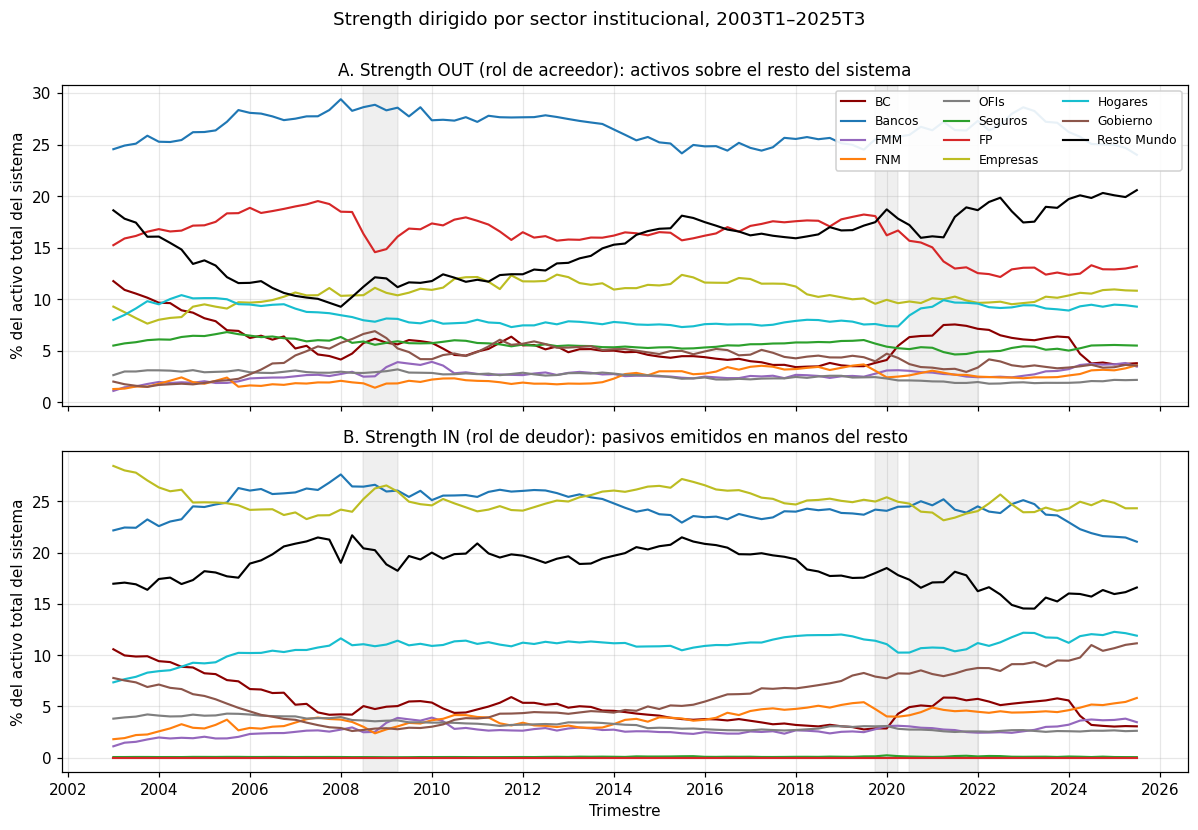

In [31]:
# Definición de bandas de episodios (consistente con tabla 8 de la tesis)
EPISODIOS = [
    ("GFC", "2008-07-01", "2009-04-01"),
    ("Estallido", "2019-10-01", "2020-04-01"),
    ("Retiros", "2020-07-01", "2022-01-01"),
]

def dibujar_episodios(ax):
    """Agrega bandas verticales para los tres episodios."""
    for nombre, ini, fin in EPISODIOS:
        ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), alpha=0.12, color="gray")

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)

for idx, (medida, titulo, ylabel) in enumerate([
    ("s_out_pct", "A. Strength OUT (rol de acreedor): activos sobre el resto del sistema", "% del activo total del sistema"),
    ("s_in_pct",  "B. Strength IN (rol de deudor): pasivos emitidos en manos del resto",   "% del activo total del sistema"),
]):
    ax = axes[idx]
    dibujar_episodios(ax)
    for s in SECTORES_TODOS:
        sub = panel[panel["sector"] == s].sort_values("fecha")
        ax.plot(sub["fecha"], sub[medida],
                label=ETIQUETAS[s], color=COLORES[s], linewidth=1.4)
    ax.set_title(titulo)
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[1].set_xlabel("Trimestre")
axes[0].legend(loc="upper right", ncol=3, fontsize=8, framealpha=0.9)

fig.suptitle("Strength dirigido por sector institucional, 2003T1–2025T3", fontsize=12, y=1.00)
fig.tight_layout()
#fig.savefig(OUTPUT_DIR / "fig_strength.png", bbox_inches="tight")
plt.show()

**Interpretación esperada de la figura:**

- Bancos y Resto del Mundo deben dominar en ambos paneles (sectores grandes).
- FP debe aparecer muy alto en Panel A (rol de acreedor) y ausente o mínimo en Panel B (no tiene pasivos en la red, por construcción CNSI).
- Banco Central debe mostrar un salto visible en Panel A durante 2020–2021 asociado a las medidas de mitigación (FCIC, compra de bonos bancarios).
- Hogares en Panel B (rol de deudor) deben crecer gradualmente, reflejando la expansión del crédito.

Cualquier desviación de este patrón merece investigación adicional antes de seguir.

## 5. Asimetría direccional $\alpha_i$

Esta es la métrica que mejor captura el **rol funcional** de cada sector dentro de la red.

$$\alpha_i(t) = \frac{s_i^{\text{out}}(t)}{s_i^{\text{out}}(t) + s_i^{\text{in}}(t)}$$

Lectura:

- $\alpha \approx 1$ → puro acreedor (financia al sistema sin endeudarse en él).
- $\alpha \approx 0$ → puro deudor (financiado por el sistema sin financiar).
- $\alpha \approx 0.5$ → balanceado (intermediario clásico).

**Importancia para tu tesis**: el VAR-DY captura que FP transita de transmisor neto a receptor neto durante los retiros. La asimetría $\alpha$ es la **versión cruda y contable** de ese mismo fenómeno. Si ambos indicadores se mueven en la misma dirección, el hallazgo se refuerza por triangulación.

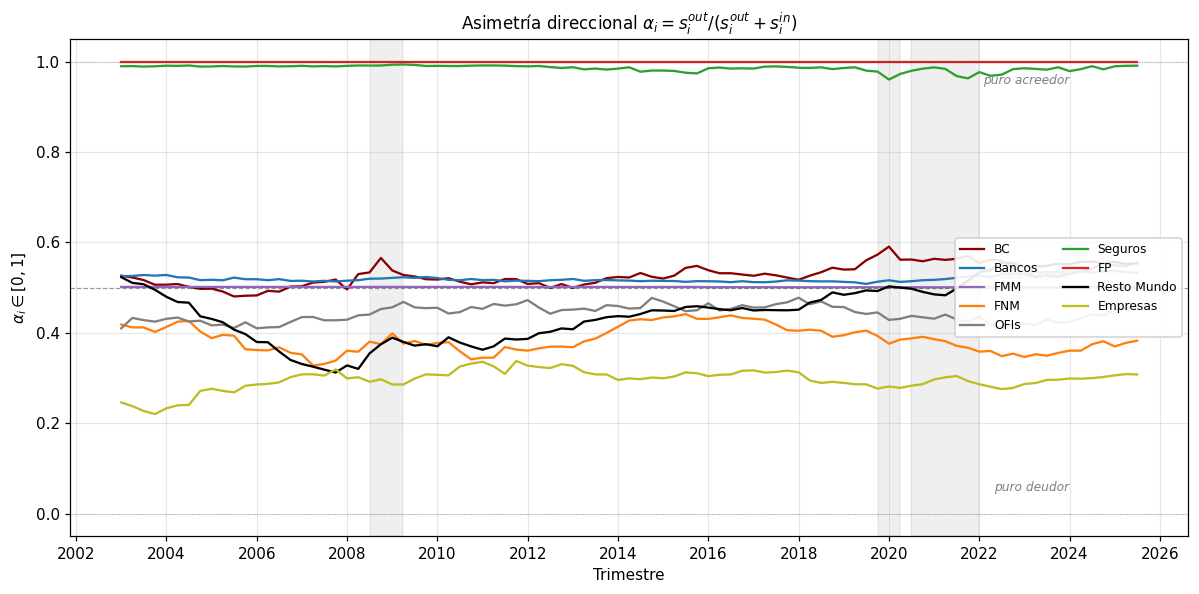

In [32]:
# Asimetría: ya está calculada en `panel` como columna alpha
# Visualizamos solo los sectores financieros (los que tienen interpretación clara)
# y agregamos Resto del Mundo y Empresas como referencia

sectores_alpha = ["S121", "S122", "S123", "S124", "S125_S126", "S128", "S129", "S2", "S11"]

fig, ax = plt.subplots(figsize=(11, 5.5))
dibujar_episodios(ax)

for s in sectores_alpha:
    sub = panel[panel["sector"] == s].sort_values("fecha")
    ax.plot(sub["fecha"], sub["alpha"],
            label=ETIQUETAS[s], color=COLORES[s], linewidth=1.5)

# Líneas de referencia
ax.axhline(0.5, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
ax.axhline(1.0, color="black", linestyle=":", alpha=0.3, linewidth=0.6)
ax.axhline(0.0, color="black", linestyle=":", alpha=0.3, linewidth=0.6)

# Anotaciones de los regímenes
ax.text(pd.Timestamp("2024-01-01"), 0.95, "puro acreedor", fontsize=8,
        style="italic", color="gray", ha="right")
ax.text(pd.Timestamp("2024-01-01"), 0.52, "balanceado",  fontsize=8,
        style="italic", color="gray", ha="right")
ax.text(pd.Timestamp("2024-01-01"), 0.05, "puro deudor", fontsize=8,
        style="italic", color="gray", ha="right")

ax.set_title("Asimetría direccional $\\alpha_i = s^{out}_i / (s^{out}_i + s^{in}_i)$")
ax.set_ylabel(r"$\alpha_i \in [0,1]$")
ax.set_xlabel("Trimestre")
ax.set_ylim(-0.05, 1.05)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="center right", ncol=2, fontsize=8, framealpha=0.9)

fig.tight_layout()
#fig.savefig(OUTPUT_DIR / "fig_asimetria.png", bbox_inches="tight")
plt.show()

### 5.1 Zoom: ¿qué sectores cambian de rol funcional durante los episodios?

La figura anterior muestra muchas series. Para identificar cambios de rol, calculamos la **variación de $\alpha$** entre tres ventanas:

- **Pre-pandemia**: promedio 2003T1–2019T4.
- **Retiros + pandemia**: promedio 2020T1–2021T4.
- **Post-retiros**: promedio 2022T1–2025T3.

Sectores con cambios mayores a 5 puntos porcentuales en $\alpha$ son candidatos a **cambio de rol funcional**.

In [33]:
def asignar_episodio(p):
    fecha = periodo_a_fecha(p)
    if fecha < pd.Timestamp("2020-01-01"):
        return "Pre-pandemia (2003-2019)"
    elif fecha < pd.Timestamp("2022-01-01"):
        return "Retiros+pandemia (2020-2021)"
    else:
        return "Post-retiros (2022-2025)"

panel["episodio"] = panel["periodo"].map(asignar_episodio)

resumen_alpha = (panel
    .groupby(["sector", "episodio"])["alpha"]
    .mean()
    .unstack("episodio")
    [["Pre-pandemia (2003-2019)", "Retiros+pandemia (2020-2021)", "Post-retiros (2022-2025)"]]
)
resumen_alpha["Δ Pre→Retiros"] = resumen_alpha["Retiros+pandemia (2020-2021)"] - resumen_alpha["Pre-pandemia (2003-2019)"]
resumen_alpha["Δ Pre→Post"] = resumen_alpha["Post-retiros (2022-2025)"] - resumen_alpha["Pre-pandemia (2003-2019)"]

# Reordenamos por magnitud del cambio durante retiros
resumen_alpha = resumen_alpha.reindex(SECTORES_TODOS)
resumen_alpha.index = [ETIQUETAS[s] for s in resumen_alpha.index]

print("Asimetría direccional α por episodio (medias)")
print("=" * 90)
print(resumen_alpha.round(3).to_string())
print()
print("Sectores con cambio absoluto > 0.05 entre pre-pandemia y retiros:")
candidatos = resumen_alpha[resumen_alpha["Δ Pre→Retiros"].abs() > 0.05]
for nombre in candidatos.index:
    delta = candidatos.loc[nombre, "Δ Pre→Retiros"]
    signo = "↑ más acreedor" if delta > 0 else "↓ más deudor"
    print(f"  {nombre:15s}  Δ = {delta:+.3f}   {signo}")

#resumen_alpha.to_csv(OUTPUT_DIR / "tabla_asimetria.csv")

Asimetría direccional α por episodio (medias)
episodio     Pre-pandemia (2003-2019)  Retiros+pandemia (2020-2021)  Post-retiros (2022-2025)  Δ Pre→Retiros  Δ Pre→Post
BC                              0.519                         0.567                     0.543          0.048       0.024
Bancos                          0.517                         0.518                     0.533          0.001       0.016
FMM                             0.502                         0.501                     0.501         -0.001      -0.001
FNM                             0.391                         0.381                     0.362         -0.010      -0.029
OFIs                            0.446                         0.432                     0.431         -0.014      -0.015
Seguros                         0.988                         0.975                     0.983         -0.013      -0.005
FP                              1.000                         1.000                     1.000          0.00

## 6. Mapa funcional: scatter $s^{out}$ vs $s^{in}$

Una visualización compacta que ubica a cada sector en el plano (tamaño como acreedor, tamaño como deudor) en dos momentos: pre-pandemia y post-retiros. Los sectores que se mueven sobre la diagonal mantienen su rol funcional; los que se desvían cambian de rol.

- **Encima de la diagonal**: más acreedor que deudor.
- **Sobre la diagonal**: balanceado.
- **Bajo la diagonal**: más deudor que acreedor.

El tamaño del marcador es proporcional al strength total ($s^{out} + s^{in}$), por lo que la figura también muestra **tamaño relativo** dentro del sistema.

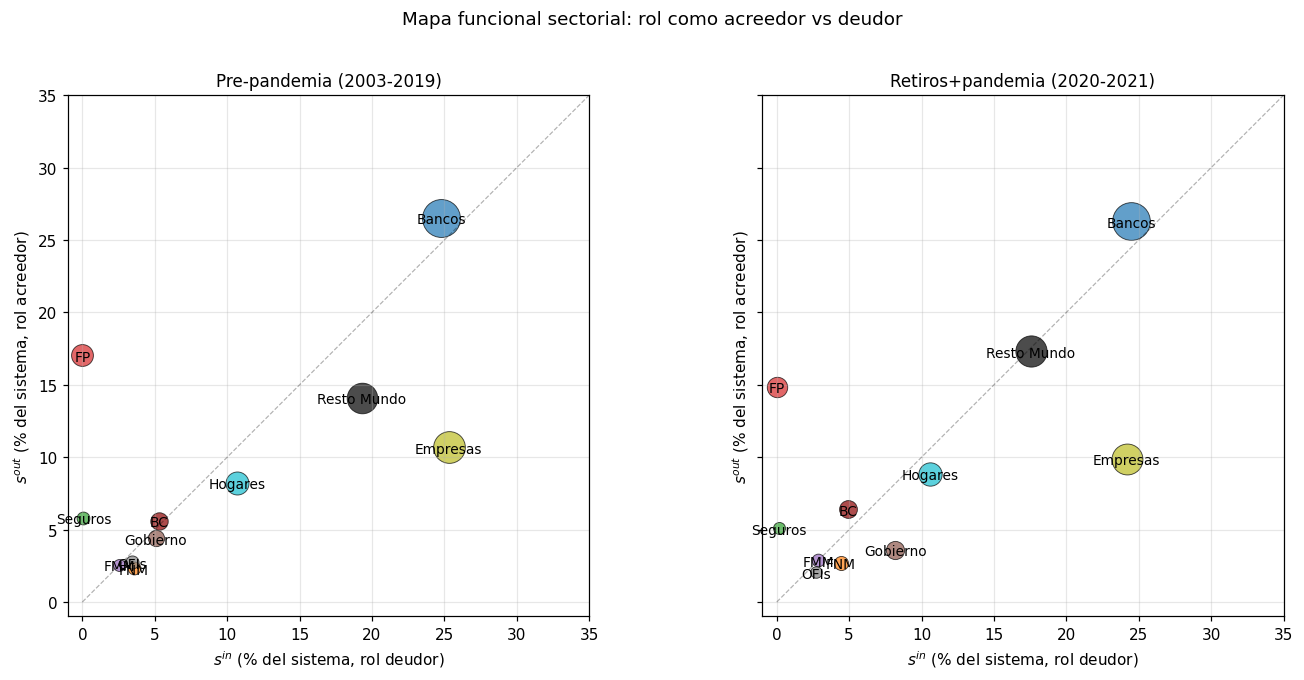

In [38]:
# Calculamos promedios por sector × episodio
mapa = (panel
    .groupby(["sector", "episodio"])[["s_out_pct", "s_in_pct"]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

ventanas = [
    ("Pre-pandemia (2003-2019)", axes[0]),
    ("Retiros+pandemia (2020-2021)", axes[1]),
    #("Post-retiros (2022-2025)", axes[2]),
]

for nombre_ep, ax in ventanas:
    sub = mapa[mapa["episodio"] == nombre_ep]
    for _, row in sub.iterrows():
        s = row["sector"]
        size = max(40, 12 * (row["s_out_pct"] + row["s_in_pct"]))
        ax.scatter(row["s_in_pct"], row["s_out_pct"],
                   s=size, color=COLORES[s], alpha=0.7,
                   edgecolors="black", linewidth=0.6)
        ax.annotate(ETIQUETAS[s],
                    (row["s_in_pct"], row["s_out_pct"]),
                    fontsize=9, ha="center", va="center",
                    xytext=(0, -1), textcoords="offset points")

    # Diagonal de balance
    lim = 35
    ax.plot([0, lim], [0, lim], color="black", linestyle="--", alpha=0.3, linewidth=0.8)
    ax.set_xlim(-1, lim)
    ax.set_ylim(-1, lim)
    ax.set_xlabel("$s^{in}$ (% del sistema, rol deudor)")
    ax.set_ylabel("$s^{out}$ (% del sistema, rol acreedor)")
    ax.set_title(nombre_ep)
    ax.set_aspect("equal")

fig.suptitle("Mapa funcional sectorial: rol como acreedor vs deudor",
             fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_scatter_funcional.png", bbox_inches="tight")
plt.show()

## 7. Tabla resumen final

Construimos la tabla maestra que resume las tres métricas por sector y episodio. Esta tabla es candidata directa a aparecer en el capítulo 5.A de la tesis (puede reemplazar parcialmente a la Tabla 4 actual del documento).

In [35]:
tabla_final = (panel
    .groupby(["sector", "episodio"])
    .agg(
        s_out_pct=("s_out_pct", "mean"),
        s_in_pct=("s_in_pct", "mean"),
        alpha=("alpha", "mean"),
    )
    .reset_index()
)

# Pivot para presentación
def construir_tabla_pivot(df_in, var):
    p = df_in.pivot(index="sector", columns="episodio", values=var)
    p = p[["Pre-pandemia (2003-2019)", "Retiros+pandemia (2020-2021)", "Post-retiros (2022-2025)"]]
    p = p.reindex(SECTORES_TODOS)
    p.index = [ETIQUETAS[s] for s in p.index]
    return p

print("S_OUT (% del sistema, rol acreedor):")
print("=" * 80)
print(construir_tabla_pivot(tabla_final, "s_out_pct").round(2).to_string())
print()
print("S_IN (% del sistema, rol deudor):")
print("=" * 80)
print(construir_tabla_pivot(tabla_final, "s_in_pct").round(2).to_string())
print()
print("α (asimetría direccional):")
print("=" * 80)
print(construir_tabla_pivot(tabla_final, "alpha").round(3).to_string())

tabla_final.to_csv(OUTPUT_DIR / "tabla_resumen_capa1.csv", index=False)

S_OUT (% del sistema, rol acreedor):
episodio     Pre-pandemia (2003-2019)  Retiros+pandemia (2020-2021)  Post-retiros (2022-2025)
BC                               5.61                          6.41                      5.44
Bancos                          26.55                         26.31                     26.36
FMM                              2.55                          2.88                      3.09
FNM                              2.32                          2.71                      2.74
OFIs                             2.73                          2.06                      1.97
Seguros                          5.81                          5.08                      5.28
FP                              17.04                         14.85                     12.75
Empresas                        10.69                          9.90                     10.23
Hogares                          8.22                          8.85                      9.28
Gobierno               

## 8. Discusión e integración con DY

**Patrones esperados según hechos estilizados de la tesis** (puntos a verificar al ver los resultados):

1. **Bancos como nodo central, pero con $\alpha \approx 0.5$**: deben aparecer tan grandes como acreedores como deudores, consistente con su rol de intermediación clásica.

2. **Fondos de Pensiones como puro acreedor ($\alpha \approx 1$)**: por construcción CNSI, los pasivos previsionales con hogares están fuera de la red. Esto es la representación correcta del rol activo de los FP como financistas del sistema.

3. **Banco Central con salto de $s^{out}$ durante retiros**: las medidas FCIC y CC-VP del BCCh implican adquisición masiva de títulos y préstamos bancarios. Esto debe verse claramente en Panel A entre 2020T2 y 2021T4.

4. **Resto del Mundo creciendo en $s^{out}$ en la última década**: consistente con apertura financiera y mayor tenencia extranjera de instrumentos chilenos (mencionado en hechos estilizados II de la tesis).

5. **Hogares con $\alpha$ bajo (puro deudor)**: créditos hipotecarios y de consumo dominan. Su strength IN debe ser mayor que su OUT.

**Conexión con Diebold-Yilmaz**:

El indicador $\alpha_i(t)$ es la **versión contable cruda** del concepto NET direccional de DY. Mientras DY mide propagación dinámica de shocks en varianzas de tasas de crecimiento, $\alpha$ mide la **estructura de saldos en el balance**. Si ambos indicadores apuntan en la misma dirección durante los retiros (FP perdiendo rol de acreedor neto), el hallazgo de la tesis se refuerza por **triangulación entre evidencia contable y evidencia econométrica**. Si difieren, vale la pena explorar por qué.

## 9. Archivos generados

Lista de outputs que quedan disponibles:

In [36]:
print("Archivos generados en", OUTPUT_DIR)
print("=" * 60)
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name:40s}  ({f.stat().st_size / 1024:.1f} KB)")

Archivos generados en ../../3_resultados/3_resultados_he_red/figuras/2_indices
  .DS_Store                                 (6.0 KB)
  fig_scatter_funcional.png                 (119.4 KB)
  tabla_resumen_capa1.csv                   (2.8 KB)
